# Session XII — 32 Virtual GPUs + ZeRO-1 / ZeRO-2 / ZeRO-3

Educational simulator: **32 virtual GPUs** (CPU threads), a tiny demo MLP, and closed-form memory that matches the lecture ladder for a 30B model.

This is **not** DeepSpeed/FSDP — it is a teaching model of what each ZeRO stage keeps resident and how communication grows as we shard more.

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if (ROOT / "zero_sim.py").exists():
    pass
elif (ROOT / "Session-XII" / "zero_sim.py").exists():
    ROOT = ROOT / "Session-XII"
    sys.path.insert(0, str(ROOT))
else:
    sys.path.insert(0, str(ROOT))

from zero_sim import (
    WORLD_SIZE_DEFAULT,
    ZeroStage,
    compare_all_stages,
    format_bytes,
    lecture_30b_table,
    memory_for_stage,
    simulate_stage,
)

print("world size:", WORLD_SIZE_DEFAULT)
print("ok")

world size: 32
ok


## What each stage shards

| Stage | Params (fp16, 2 B) | Grads (fp16, 2 B) | Optim (fp32+m+v, 12 B) |
|-------|--------------------|-------------------|-------------------------|
| DP (ZeRO-0) | full | full | full |
| ZeRO-1 | full | full | **1/N** |
| ZeRO-2 | full | **1/N** | **1/N** |
| ZeRO-3 | **1/N** | **1/N** | **1/N** |

Baseline under BF16 + Adam: **16 bytes per parameter per GPU** in plain data parallel (lecture).

In [2]:
# Closed-form check: 30B @ 8 GPUs should ≈ lecture (447 / 153 / ~105 / 55 GiB)
for n in (8, 32, 64):
    print(f"\n=== 30B params, world_size={n} ===")
    for s, m in lecture_30b_table(n).items():
        gb = m.as_gb()
        print(f"  {s:6s}  per-GPU {gb['per_gpu_GiB']:8.1f} GiB   "
              f"comm/step {gb['comm_GiB_per_step']:7.2f} GiB")


=== 30B params, world_size=8 ===
  dp      per-GPU    447.0 GiB   comm/step  111.76 GiB
  zero1   per-GPU    153.7 GiB   comm/step  167.64 GiB
  zero2   per-GPU    104.8 GiB   comm/step  111.76 GiB
  zero3   per-GPU     55.9 GiB   comm/step  167.64 GiB

=== 30B params, world_size=32 ===
  dp      per-GPU    447.0 GiB   comm/step  111.76 GiB
  zero1   per-GPU    122.2 GiB   comm/step  167.64 GiB
  zero2   per-GPU     68.1 GiB   comm/step  111.76 GiB
  zero3   per-GPU     14.0 GiB   comm/step  167.64 GiB

=== 30B params, world_size=64 ===
  dp      per-GPU    447.0 GiB   comm/step  111.76 GiB
  zero1   per-GPU    117.0 GiB   comm/step  167.64 GiB
  zero2   per-GPU     62.0 GiB   comm/step  111.76 GiB
  zero3   per-GPU      7.0 GiB   comm/step  167.64 GiB


## Run the demo on 32 virtual GPUs

Each rank is a thread. Every rank runs forward + backward on its own micro-batch, then we simulate the collective (all-reduce / reduce-scatter style average) and an Adam-like update on the shard that rank owns.

In [3]:
runs = compare_all_stages(world_size=32, width=256, depth=4, batch=8, seed=0)

print(f"{'stage':<8} {'params':>10} {'per-GPU':>14} {'comm/step':>14} {'wall_ms':>10} {'compute%':>10} {'loss':>8}")
for name, r in runs.items():
    print(
        f"{name:<8} {r.num_params:>10d} "
        f"{format_bytes(r.accounting.total_per_gpu_bytes):>14} "
        f"{format_bytes(r.accounting.comm_bytes_per_step):>14} "
        f"{r.wall_ms:>10.1f} {100*r.compute_fraction:>9.1f}% {r.mean_loss:>8.4f}"
    )
    print("   ", r.notes)

stage        params        per-GPU      comm/step    wall_ms   compute%     loss
dp           230464      3.517 MiB    900.250 KiB      423.1      88.4%   4.1602
    Full params+grads+optim on every GPU. Cheapest comm, fattest memory.
zero1        230464    984.648 KiB      1.319 MiB      275.1      83.6%   4.1638
    Optimizer (12B/param) sharded. Still full model+grads. Saves ~12Ψ(1-1/N).
zero2        230464    548.590 KiB    900.250 KiB      300.7      88.4%   4.1546
    Optimizer + grads sharded. Full params. Reduce-scatter grads.
zero3        230464    112.531 KiB      1.319 MiB      233.9      83.6%   4.1608
    Everything sharded. All-gather params to compute. Highest comm, lowest memory.


## Memory breakdown (demo model)

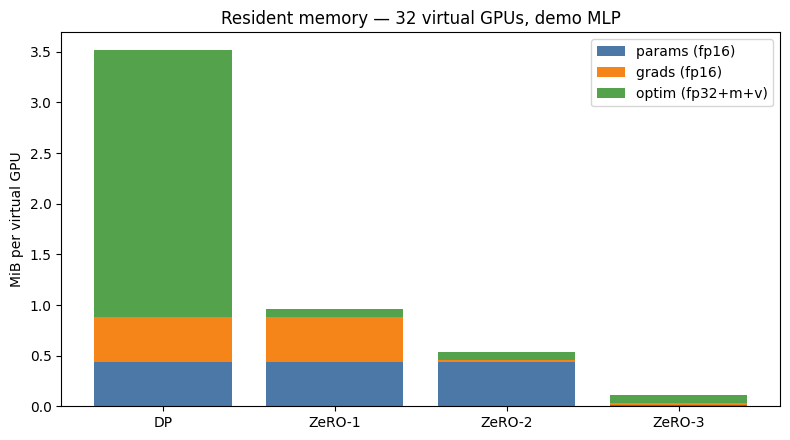

In [4]:
import matplotlib.pyplot as plt
import numpy as np

stages = ["dp", "zero1", "zero2", "zero3"]
labels = ["DP", "ZeRO-1", "ZeRO-2", "ZeRO-3"]
params_b = [runs[s].accounting.params_bytes / 1024**2 for s in stages]
grads_b  = [runs[s].accounting.grads_bytes  / 1024**2 for s in stages]
optim_b  = [runs[s].accounting.optim_bytes  / 1024**2 for s in stages]
x = np.arange(len(stages))

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x, params_b, label="params (fp16)", color="#4c78a8")
ax.bar(x, grads_b, bottom=params_b, label="grads (fp16)", color="#f58518")
bottom2 = [a + b for a, b in zip(params_b, grads_b)]
ax.bar(x, optim_b, bottom=bottom2, label="optim (fp32+m+v)", color="#54a24b")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("MiB per virtual GPU")
ax.set_title("Resident memory — 32 virtual GPUs, demo MLP")
ax.legend(); fig.tight_layout(); plt.show()

## Communication rises as memory falls

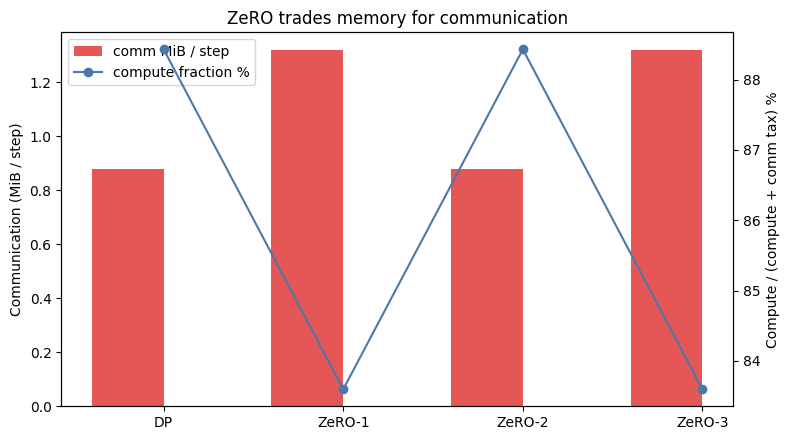

In [5]:
comm = [runs[s].accounting.comm_bytes_per_step / 1024**2 for s in stages]
comp = [100 * runs[s].compute_fraction for s in stages]

fig, ax1 = plt.subplots(figsize=(8, 4.5))
ax1.bar(x - 0.2, comm, width=0.4, color="#e45756", label="comm MiB / step")
ax1.set_ylabel("Communication (MiB / step)")
ax2 = ax1.twinx()
ax2.plot(x, comp, "o-", color="#4c78a8", label="compute fraction %")
ax2.set_ylabel("Compute / (compute + comm tax) %")
ax1.set_xticks(x); ax1.set_xticklabels(labels)
ax1.set_title("ZeRO trades memory for communication")
h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="best")
fig.tight_layout(); plt.show()

## Lecture ladder: 30B model vs world size

DP stays at **447 GiB/GPU** no matter how many GPUs you add — you only get more copies. ZeRO-3 falls as 16Ψ/N.

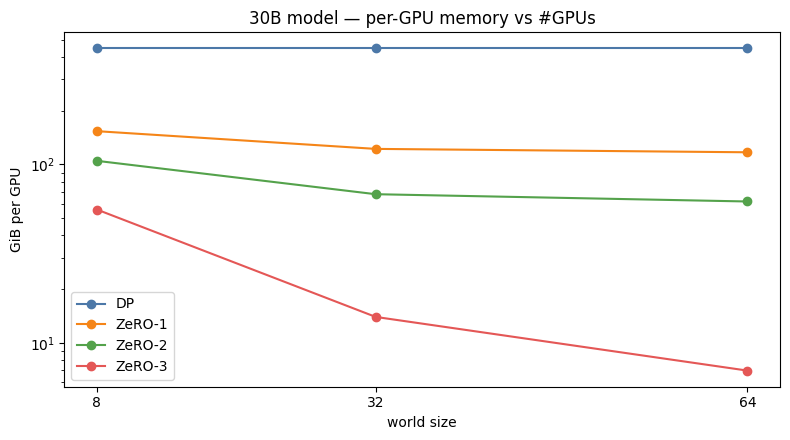

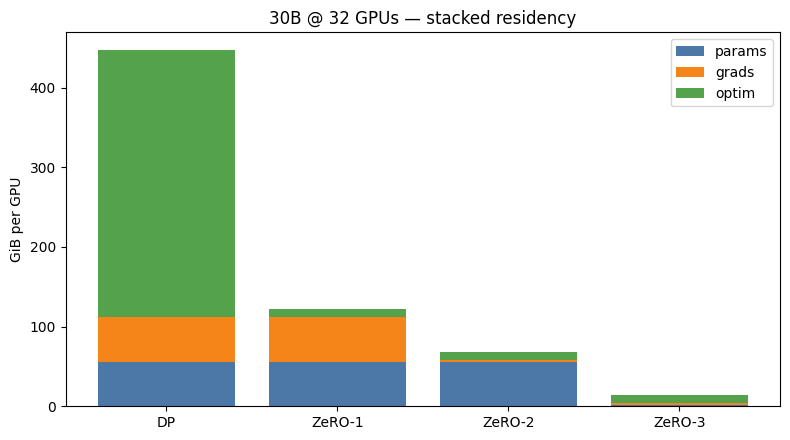

In [6]:
ws = [8, 32, 64]
colors = ["#4c78a8", "#f58518", "#54a24b", "#e45756"]
fig, ax = plt.subplots(figsize=(8, 4.5))
for s, lab, c in zip(stages, labels, colors):
    ys = [lecture_30b_table(n)[s].as_gb()["per_gpu_GiB"] for n in ws]
    ax.plot(ws, ys, "o-", label=lab, color=c)
ax.set_xlabel("world size"); ax.set_ylabel("GiB per GPU")
ax.set_title("30B model — per-GPU memory vs #GPUs")
ax.set_xticks(ws); ax.set_yscale("log"); ax.legend()
fig.tight_layout(); plt.show()

# stacked @ 32 GPUs
psi = 30_000_000_000
n = 32
pb, gb_, ob = [], [], []
for s in ZeroStage:
    m = memory_for_stage(s, psi, n)
    pb.append(m.params_bytes / 1024**3)
    gb_.append(m.grads_bytes / 1024**3)
    ob.append(m.optim_bytes / 1024**3)
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.bar(x, pb, label="params", color="#4c78a8")
ax.bar(x, gb_, bottom=pb, label="grads", color="#f58518")
b2 = [a + b for a, b in zip(pb, gb_)]
ax.bar(x, ob, bottom=b2, label="optim", color="#54a24b")
ax.set_xticks(x); ax.set_xticklabels(labels)
ax.set_ylabel("GiB per GPU")
ax.set_title("30B @ 32 GPUs — stacked residency")
ax.legend(); fig.tight_layout(); plt.show()

## Takeaway for me

- **DP** copies everything → memory does not shrink with more GPUs.
- **ZeRO-1** shards the fat Adam states (12 of the 16 bytes).
- **ZeRO-2** also shards grads (reduce-scatter).
- **ZeRO-3** shards weights too → you can fit huge models, but you pay all-gather on every layer.
- Pick the stage from an Excel sheet: if the step is short, extra communication between nodes can dominate (lecture point about 2.4 s fabric tax).